In [1]:
import os
import gc
import copy
import json
import time
import random
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, models, transforms

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, confusion_matrix

print("PyTorch version:", torch.__version__)

SEED = 42

NUM_CLASSES = 10
IMAGE_SIZE = 224
BATCH_SIZE = 32
MAX_EPOCHS = 25
PATIENCE = 4
MIN_DELTA = 1e-4

LR_SCRATCH = 1e-3
LR_HEAD = 1e-3
LR_BACKBONE = 1e-4
WEIGHT_DECAY = 1e-2

NUM_WORKERS = 2 if os.name != "nt" else 0
PIN_MEMORY = torch.cuda.is_available()

RUN_B5 = True

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

if device.type != "cuda":
    print("WARNING: GPU tidak terdeteksi. Aktifkan T4 GPU di Colab agar training lebih cepat.")

PyTorch version: 2.11.0+cu130
Device: cuda


In [2]:
def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed()
print("Seed set to:", SEED)

Seed set to: 42


In [3]:
DATA_ROOT = Path("data")

trainval_base = datasets.OxfordIIITPet(
    root=DATA_ROOT,
    split="trainval",
    target_types="category",
    download=True,
    transform=None,
)

test_base = datasets.OxfordIIITPet(
    root=DATA_ROOT,
    split="test",
    target_types="category",
    download=True,
    transform=None,
)

print("Built-in trainval size:", len(trainval_base))
print("Built-in test size    :", len(test_base))

100%|██████████| 792M/792M [00:07<00:00, 101MB/s]
100%|██████████| 19.2M/19.2M [00:00<00:00, 128MB/s] 


Built-in trainval size: 3680
Built-in test size    : 3669


In [4]:
def get_class_names(ds):
    if hasattr(ds, "classes"):
        return list(ds.classes)
    if hasattr(ds, "_classes"):
        return list(ds._classes)
    raise AttributeError("Class names tidak ditemukan pada OxfordIIITPet object.")

def normalize_class_name(name):
    return (
        str(name)
        .strip()
        .lower()
        .replace("-", "_")
        .replace(" ", "_")
    )

all_class_names = get_class_names(trainval_base)

print("Number of original classes:", len(all_class_names))
print(all_class_names)

Number of original classes: 37
['Abyssinian', 'American Bulldog', 'American Pit Bull Terrier', 'Basset Hound', 'Beagle', 'Bengal', 'Birman', 'Bombay', 'Boxer', 'British Shorthair', 'Chihuahua', 'Egyptian Mau', 'English Cocker Spaniel', 'English Setter', 'German Shorthaired', 'Great Pyrenees', 'Havanese', 'Japanese Chin', 'Keeshond', 'Leonberger', 'Maine Coon', 'Miniature Pinscher', 'Newfoundland', 'Persian', 'Pomeranian', 'Pug', 'Ragdoll', 'Russian Blue', 'Saint Bernard', 'Samoyed', 'Scottish Terrier', 'Shiba Inu', 'Siamese', 'Sphynx', 'Staffordshire Bull Terrier', 'Wheaten Terrier', 'Yorkshire Terrier']


In [5]:
SELECTED_CLASSES = [
    "Abyssinian",
    "Bengal",
    "Birman",
    "Bombay",
    "British_Shorthair",

    "beagle",
    "boxer",
    "chihuahua",
    "pug",
    "samoyed",
]

name_to_original_index = {
    normalize_class_name(name): idx
    for idx, name in enumerate(all_class_names)
}

selected_original_indices = []
resolved_selected_names = []

for wanted_name in SELECTED_CLASSES:
    key = normalize_class_name(wanted_name)

    if key not in name_to_original_index:
        raise ValueError(
            f"Class '{wanted_name}' tidak ditemukan.\n"
            f"Available classes:\n{all_class_names}"
        )

    original_idx = name_to_original_index[key]
    selected_original_indices.append(original_idx)
    resolved_selected_names.append(all_class_names[original_idx])

print("Selected classes:")
for i, name in enumerate(resolved_selected_names):
    print(f"{i}: {name}")

Selected classes:
0: Abyssinian
1: Bengal
2: Birman
3: Bombay
4: British Shorthair
5: Beagle
6: Boxer
7: Chihuahua
8: Pug
9: Samoyed


In [6]:
def extract_raw_labels(ds):
    for attr in ["_labels", "targets", "labels"]:
        if hasattr(ds, attr):
            values = getattr(ds, attr)
            return [int(x) for x in values]

    return [int(ds[i][1]) for i in range(len(ds))]

def detect_label_offset(labels, n_classes):
    lo, hi = min(labels), max(labels)

    if lo == 0 and hi <= n_classes - 1:
        return 0
    if lo == 1 and hi <= n_classes:
        return 1

    raise ValueError(f"Unexpected label range: min={lo}, max={hi}")

tv_labels = extract_raw_labels(trainval_base)
te_labels = extract_raw_labels(test_base)

tv_offset = detect_label_offset(tv_labels, len(all_class_names))
te_offset = detect_label_offset(te_labels, len(all_class_names))

orig_to_new = {
    orig_idx: new_idx
    for new_idx, orig_idx in enumerate(selected_original_indices)
}

records = []

for source_name, ds, labels, offset in [
    ("trainval", trainval_base, tv_labels, tv_offset),
    ("test", test_base, te_labels, te_offset),
]:
    for base_idx, raw_label in enumerate(labels):
        class_idx = raw_label - offset

        if class_idx in orig_to_new:
            new_label = orig_to_new[class_idx]

            records.append({
                "source": source_name,
                "base_idx": base_idx,
                "original_class_idx": class_idx,
                "new_label": new_label,
                "class_name": all_class_names[class_idx],
            })

records_df = pd.DataFrame(records)

print("Total selected images:", len(records_df))
display(
    records_df["class_name"]
    .value_counts()
    .sort_index()
    .rename("count")
    .to_frame()
)

Total selected images: 1981


,count
class_name,
Abyssinian,198
Beagle,200
Bengal,200
Birman,200
Bombay,184
Boxer,199
British Shorthair,200
Chihuahua,200
Pug,200


In [7]:
all_indices = np.arange(len(records_df))
all_labels = records_df["new_label"].to_numpy()

train_indices, temp_indices = train_test_split(
    all_indices,
    test_size=0.30,
    random_state=SEED,
    stratify=all_labels,
)

val_indices, test_indices = train_test_split(
    temp_indices,
    test_size=0.50,
    random_state=SEED,
    stratify=all_labels[temp_indices],
)

print("Train:", len(train_indices), f"({len(train_indices)/len(records_df):.1%})")
print("Val  :", len(val_indices), f"({len(val_indices)/len(records_df):.1%})")
print("Test :", len(test_indices), f"({len(test_indices)/len(records_df):.1%})")

def split_distribution(indices, name):
    dist = (
        records_df.iloc[indices]["class_name"]
        .value_counts()
        .reindex(resolved_selected_names)
        .fillna(0)
        .astype(int)
    )
    return dist.rename(name)

distribution_df = pd.concat([
    split_distribution(train_indices, "train"),
    split_distribution(val_indices, "validation"),
    split_distribution(test_indices, "test"),
], axis=1)

display(distribution_df)

Train: 1386 (70.0%)
Val  : 297 (15.0%)
Test : 298 (15.0%)


,train,validation,test
class_name,,,
Abyssinian,138,30,30
Bengal,140,30,30
Birman,140,30,30
Bombay,129,27,28
British Shorthair,140,30,30
Beagle,140,30,30
Boxer,139,30,30
Chihuahua,140,30,30
Pug,140,30,30


In [8]:
class OxfordPoolSubset(Dataset):
    def __init__(
        self,
        records_df,
        indices,
        trainval_base,
        test_base,
        transform=None,
    ):
        self.records_df = records_df.reset_index(drop=True)
        self.indices = list(map(int, indices))
        self.trainval_base = trainval_base
        self.test_base = test_base
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def _load_raw_from_record_idx(self, record_idx):
        row = self.records_df.iloc[int(record_idx)]

        if row["source"] == "trainval":
            image, _ = self.trainval_base[int(row["base_idx"])]
        elif row["source"] == "test":
            image, _ = self.test_base[int(row["base_idx"])]
        else:
            raise ValueError(f"Unknown source: {row['source']}")

        label = int(row["new_label"])
        return image, label

    def __getitem__(self, idx):
        record_idx = self.indices[idx]
        image, label = self._load_raw_from_record_idx(record_idx)

        if self.transform is not None:
            image = self.transform(image)

        return image, label, record_idx

    def get_raw_by_record_idx(self, record_idx):
        return self._load_raw_from_record_idx(record_idx)

In [9]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform_aug = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

train_transform_no_aug = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

def make_loaders(use_augmentation=True):
    train_transform = (
        train_transform_aug if use_augmentation
        else train_transform_no_aug
    )

    train_ds = OxfordPoolSubset(
        records_df,
        train_indices,
        trainval_base,
        test_base,
        transform=train_transform,
    )

    val_ds = OxfordPoolSubset(
        records_df,
        val_indices,
        trainval_base,
        test_base,
        transform=eval_transform,
    )

    test_ds = OxfordPoolSubset(
        records_df,
        test_indices,
        trainval_base,
        test_base,
        transform=eval_transform,
    )

    generator = torch.Generator()
    generator.manual_seed(SEED)

    train_loader = DataLoader(
        train_ds,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        generator=generator,
    )

    val_loader = DataLoader(
        val_ds,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
    )

    test_loader = DataLoader(
        test_ds,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
    )

    return train_loader, val_loader, test_loader

train_loader, val_loader, test_loader = make_loaders(use_augmentation=True)

x, y, rec_idx = next(iter(train_loader))
print("Image batch shape:", x.shape)
print("Label batch shape:", y.shape)

Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])


In [10]:
def count_parameters(model):
    trainable = sum(
        p.numel() for p in model.parameters()
        if p.requires_grad
    )
    total = sum(p.numel() for p in model.parameters())
    return trainable, total


def run_one_epoch(model, loader, criterion, optimizer=None):
    is_training = optimizer is not None

    if is_training:
      model.train()

      for module in model.modules():
          if isinstance(module, nn.modules.batchnorm._BatchNorm):
              if not any(
                  p.requires_grad for p in module.parameters()
              ):
                  module.eval()
    else:
        model.eval()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    with torch.set_grad_enabled(is_training):
        for images, targets, _ in loader:
            images = images.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True)

            if is_training:
                optimizer.zero_grad(set_to_none=True)

            logits = model(images)
            loss = criterion(logits, targets)

            if is_training:
                loss.backward()
                optimizer.step()

            batch_size = targets.size(0)

            total_loss += loss.item() * batch_size
            total_correct += (logits.argmax(dim=1) == targets).sum().item()
            total_samples += batch_size

    avg_loss = total_loss / total_samples
    accuracy = 100.0 * total_correct / total_samples

    return avg_loss, accuracy


@torch.no_grad()
def evaluate_with_details(model, loader):
    model.eval()

    y_true = []
    y_pred = []
    confidences = []
    record_indices = []

    for images, targets, rec_idx in loader:
        images = images.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)

        logits = model(images)
        probs = torch.softmax(logits, dim=1)

        conf, preds = probs.max(dim=1)

        y_true.extend(targets.cpu().tolist())
        y_pred.extend(preds.cpu().tolist())
        confidences.extend(conf.cpu().tolist())

        if torch.is_tensor(rec_idx):
            record_indices.extend(rec_idx.cpu().tolist())
        else:
            record_indices.extend(list(rec_idx))

    macro_f1 = f1_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0,
    )

    accuracy = 100.0 * np.mean(
        np.array(y_true) == np.array(y_pred)
    )

    details = pd.DataFrame({
        "record_idx": record_indices,
        "y_true": y_true,
        "y_pred": y_pred,
        "confidence": confidences,
    })

    return {
        "accuracy": accuracy,
        "macro_f1": macro_f1,
        "details": details,
    }

In [11]:
def build_resnet18(strategy):
    set_seed(SEED)

    if strategy == "B1":
        model = models.resnet18(weights=None)
        model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)

        optimizer = torch.optim.AdamW(
            model.parameters(),
            lr=LR_SCRATCH,
            weight_decay=WEIGHT_DECAY,
        )

        lr_info = {"all_parameters": LR_SCRATCH}

    elif strategy == "B2":
        weights = models.ResNet18_Weights.IMAGENET1K_V1
        model = models.resnet18(weights=weights)

        for param in model.parameters():
            param.requires_grad = False

        model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)

        optimizer = torch.optim.AdamW(
            model.fc.parameters(),
            lr=LR_HEAD,
            weight_decay=WEIGHT_DECAY,
        )

        lr_info = {"fc": LR_HEAD}

    elif strategy == "B3":
        weights = models.ResNet18_Weights.IMAGENET1K_V1
        model = models.resnet18(weights=weights)

        for param in model.parameters():
            param.requires_grad = False

        model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)

        for param in model.layer4.parameters():
            param.requires_grad = True

        optimizer = torch.optim.AdamW(
            [
                {
                    "params": model.layer4.parameters(),
                    "lr": LR_BACKBONE,
                },
                {
                    "params": model.fc.parameters(),
                    "lr": LR_HEAD,
                },
            ],
            weight_decay=WEIGHT_DECAY,
        )

        lr_info = {
            "layer4": LR_BACKBONE,
            "fc": LR_HEAD,
        }

    else:
        raise ValueError("strategy must be one of: B1, B2, B3")

    trainable, total = count_parameters(model)

    return model, optimizer, lr_info, trainable, total

In [12]:
experiment_results = {}
all_epoch_logs = []

def run_experiment(
    experiment_name,
    strategy,
    use_augmentation=True,
    architecture="resnet18",
):
    print("=" * 80)
    print(f"EXPERIMENT: {experiment_name}")
    print(f"Strategy  : {strategy}")
    print(f"Augment   : {use_augmentation}")
    print("=" * 80)

    set_seed(SEED)

    train_loader, val_loader, test_loader = make_loaders(
        use_augmentation=use_augmentation
    )

    if architecture == "resnet18":
        model, optimizer, lr_info, trainable_params, total_params = (
            build_resnet18(strategy)
        )

    elif architecture == "efficientnet_b0":
        model, optimizer, lr_info, trainable_params, total_params = (
            build_efficientnet_b0(strategy)
        )

    else:
        raise ValueError(
            f"Unsupported architecture: {architecture}"
        )

    print(f"Trainable parameters: {trainable_params:,}")
    print(f"Total parameters    : {total_params:,}")
    print("Learning rates      :", lr_info)

    if strategy == "B2":
        print("Expected B2 trainable parameters ≈ 5,130")

    model = model.to(device)
    criterion = nn.CrossEntropyLoss()

    best_val_loss = float("inf")
    best_state = None
    best_epoch = 0
    wait = 0
    history = []

    start_time = time.perf_counter()

    for epoch in range(1, MAX_EPOCHS + 1):
        train_loss, train_acc = run_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer=optimizer,
        )

        val_loss, val_acc = run_one_epoch(
            model,
            val_loader,
            criterion,
            optimizer=None,
        )

        epoch_row = {
            "experiment": experiment_name,
            "architecture": architecture,
            "strategy": strategy,
            "augmentation": use_augmentation,
            "epoch": epoch,
            "train_loss": train_loss,
            "train_accuracy": train_acc,
            "val_loss": val_loss,
            "val_accuracy": val_acc,
        }

        history.append(epoch_row)
        all_epoch_logs.append(epoch_row.copy())

        print(
            f"Epoch {epoch:02d}/{MAX_EPOCHS} | "
            f"train_loss={train_loss:.4f} | "
            f"train_acc={train_acc:.2f}% | "
            f"val_loss={val_loss:.4f} | "
            f"val_acc={val_acc:.2f}%"
        )

        if val_loss < best_val_loss - MIN_DELTA:
            best_val_loss = val_loss
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1

        if wait >= PATIENCE:
            print(f"Early stopping at epoch {epoch}.")
            break

    training_time = time.perf_counter() - start_time

    model.load_state_dict(best_state)

    best_val_loss_eval, best_val_acc = run_one_epoch(
        model,
        val_loader,
        criterion,
        optimizer=None,
    )

    test_result = evaluate_with_details(model, test_loader)

    best_epoch_row = history[best_epoch - 1]
    train_acc_at_best = best_epoch_row["train_accuracy"]
    generalization_gap = train_acc_at_best - best_val_acc

    summary = {
        "experiment": experiment_name,
        "architecture": architecture,
        "strategy": strategy,
        "augmentation": use_augmentation,
        "trainable_parameters": trainable_params,
        "total_parameters": total_params,
        "learning_rates": json.dumps(lr_info),
        "epochs_ran": len(history),
        "best_epoch": best_epoch,
        "training_time_sec": training_time,
        "best_val_loss": best_val_loss_eval,
        "best_val_accuracy": best_val_acc,
        "train_accuracy_at_best_epoch": train_acc_at_best,
        "generalization_gap_pct_points": generalization_gap,
        "test_accuracy": test_result["accuracy"],
        "test_macro_f1": test_result["macro_f1"],
    }

    model_cpu = copy.deepcopy(model).cpu()

    experiment_results[experiment_name] = {
        "summary": summary,
        "history": pd.DataFrame(history),
        "test_details": test_result["details"],
        "model": model_cpu,
        "strategy": strategy,
        "augmentation": use_augmentation,
    }

    print("\nSUMMARY")
    for k, v in summary.items():
        print(f"{k}: {v}")

    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return summary

In [13]:
b1_summary = run_experiment(
    experiment_name="B1_Scratch",
    strategy="B1",
    use_augmentation=True,
)

EXPERIMENT: B1_Scratch
Strategy  : B1
Augment   : True
Trainable parameters: 11,181,642
Total parameters    : 11,181,642
Learning rates      : {'all_parameters': 0.001}
Epoch 01/25 | train_loss=2.2691 | train_acc=20.71% | val_loss=2.1880 | val_acc=25.93%
Epoch 02/25 | train_loss=1.9634 | train_acc=29.37% | val_loss=2.0433 | val_acc=28.28%
Epoch 03/25 | train_loss=1.9341 | train_acc=31.75% | val_loss=1.8479 | val_acc=35.69%
Epoch 04/25 | train_loss=1.7666 | train_acc=39.47% | val_loss=2.2792 | val_acc=31.99%
Epoch 05/25 | train_loss=1.6924 | train_acc=41.92% | val_loss=2.4036 | val_acc=24.58%
Epoch 06/25 | train_loss=1.6089 | train_acc=44.59% | val_loss=3.3046 | val_acc=27.95%
Epoch 07/25 | train_loss=1.5654 | train_acc=47.04% | val_loss=1.5166 | val_acc=47.14%
Epoch 08/25 | train_loss=1.4419 | train_acc=52.31% | val_loss=1.6894 | val_acc=44.44%
Epoch 09/25 | train_loss=1.3780 | train_acc=52.53% | val_loss=1.8015 | val_acc=44.78%
Epoch 10/25 | train_loss=1.3491 | train_acc=51.88% | val_

In [14]:
b2_summary = run_experiment(
    experiment_name="B2_FeatureExtraction",
    strategy="B2",
    use_augmentation=True,
)

EXPERIMENT: B2_FeatureExtraction
Strategy  : B2
Augment   : True
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 178MB/s]


Trainable parameters: 5,130
Total parameters    : 11,181,642
Learning rates      : {'fc': 0.001}
Expected B2 trainable parameters ≈ 5,130
Epoch 01/25 | train_loss=1.2332 | train_acc=65.87% | val_loss=0.5478 | val_acc=89.56%
Epoch 02/25 | train_loss=0.3991 | train_acc=93.29% | val_loss=0.2796 | val_acc=95.96%
Epoch 03/25 | train_loss=0.2551 | train_acc=96.46% | val_loss=0.2305 | val_acc=95.62%
Epoch 04/25 | train_loss=0.2000 | train_acc=96.68% | val_loss=0.1892 | val_acc=95.62%
Epoch 05/25 | train_loss=0.1704 | train_acc=96.46% | val_loss=0.1750 | val_acc=96.30%
Epoch 06/25 | train_loss=0.1467 | train_acc=96.75% | val_loss=0.1682 | val_acc=94.61%
Epoch 07/25 | train_loss=0.1279 | train_acc=97.40% | val_loss=0.1524 | val_acc=96.63%
Epoch 08/25 | train_loss=0.1201 | train_acc=97.19% | val_loss=0.1341 | val_acc=96.30%
Epoch 09/25 | train_loss=0.1092 | train_acc=97.98% | val_loss=0.1288 | val_acc=97.31%
Epoch 10/25 | train_loss=0.0987 | train_acc=97.62% | val_loss=0.1244 | val_acc=96.97%
Ep

In [15]:
b3_summary = run_experiment(
    experiment_name="B3_ProgressiveFineTuning",
    strategy="B3",
    use_augmentation=True,
)

EXPERIMENT: B3_ProgressiveFineTuning
Strategy  : B3
Augment   : True
Trainable parameters: 8,398,858
Total parameters    : 11,181,642
Learning rates      : {'layer4': 0.0001, 'fc': 0.001}
Epoch 01/25 | train_loss=0.6318 | train_acc=83.12% | val_loss=0.1327 | val_acc=96.30%
Epoch 02/25 | train_loss=0.1027 | train_acc=97.91% | val_loss=0.1356 | val_acc=94.95%
Epoch 03/25 | train_loss=0.0558 | train_acc=99.13% | val_loss=0.1243 | val_acc=96.30%
Epoch 04/25 | train_loss=0.0460 | train_acc=98.77% | val_loss=0.0878 | val_acc=98.32%
Epoch 05/25 | train_loss=0.0221 | train_acc=99.57% | val_loss=0.1104 | val_acc=97.31%
Epoch 06/25 | train_loss=0.0270 | train_acc=99.21% | val_loss=0.1278 | val_acc=97.31%
Epoch 07/25 | train_loss=0.0155 | train_acc=99.86% | val_loss=0.1580 | val_acc=96.63%
Epoch 08/25 | train_loss=0.0097 | train_acc=99.93% | val_loss=0.1211 | val_acc=97.98%
Early stopping at epoch 8.

SUMMARY
experiment: B3_ProgressiveFineTuning
architecture: resnet18
strategy: B3
augmentation: T

In [16]:
b3_result = experiment_results["B3_ProgressiveFineTuning"]

b3_checkpoint_path = (
    OUTPUT_DIR / "B3_ProgressiveFineTuning_best_model_state.pt"
)

torch.save(
    {
        "architecture": "resnet18",
        "experiment": "B3_ProgressiveFineTuning",
        "classes": resolved_selected_names,
        "summary": b3_result["summary"],
        "state_dict": b3_result["model"].state_dict(),
    },
    b3_checkpoint_path,
)

print("Saved B3 checkpoint:", b3_checkpoint_path)

Saved B3 checkpoint: outputs/B3_ProgressiveFineTuning_best_model_state.pt


In [17]:
comparison_b1_b3 = pd.DataFrame([
    experiment_results["B1_Scratch"]["summary"],
    experiment_results["B2_FeatureExtraction"]["summary"],
    experiment_results["B3_ProgressiveFineTuning"]["summary"],
])

display(
    comparison_b1_b3[
        [
            "experiment",
            "trainable_parameters",
            "learning_rates",
            "epochs_ran",
            "training_time_sec",
            "best_val_accuracy",
            "test_accuracy",
            "test_macro_f1",
        ]
    ]
)

,experiment,trainable_parameters,learning_rates,epochs_ran,training_time_sec,best_val_accuracy,test_accuracy,test_macro_f1
0,B1_Scratch,11181642,"{""all_parameters"": 0.001}",11,164.442641,47.138047,52.013423,0.499684
1,B2_FeatureExtraction,5130,"{""fc"": 0.001}",24,327.852039,96.969697,96.979866,0.969933
2,B3_ProgressiveFineTuning,8398858,"{""layer4"": 0.0001, ""fc"": 0.001}",8,108.858807,98.316498,96.644295,0.966366


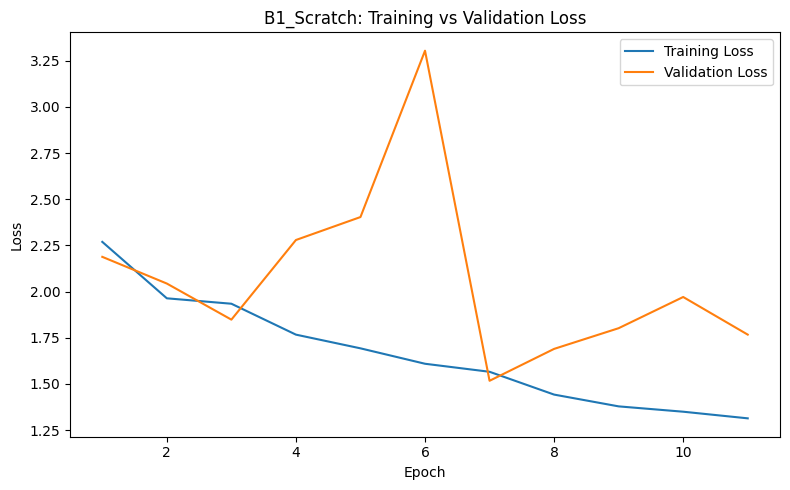

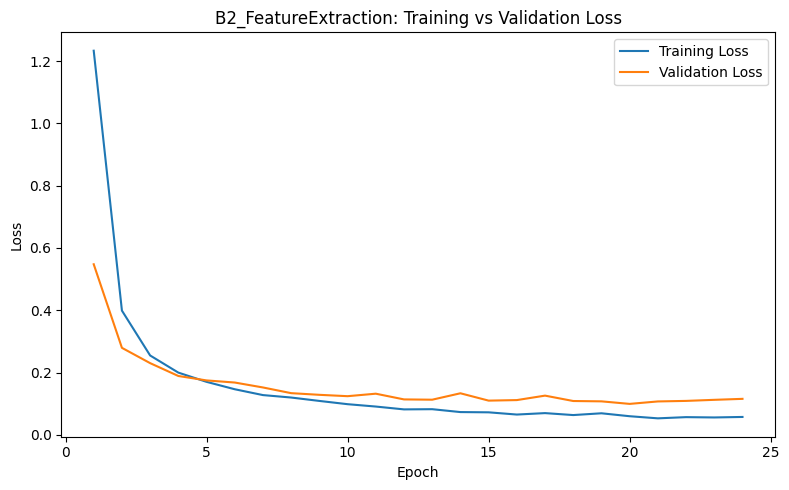

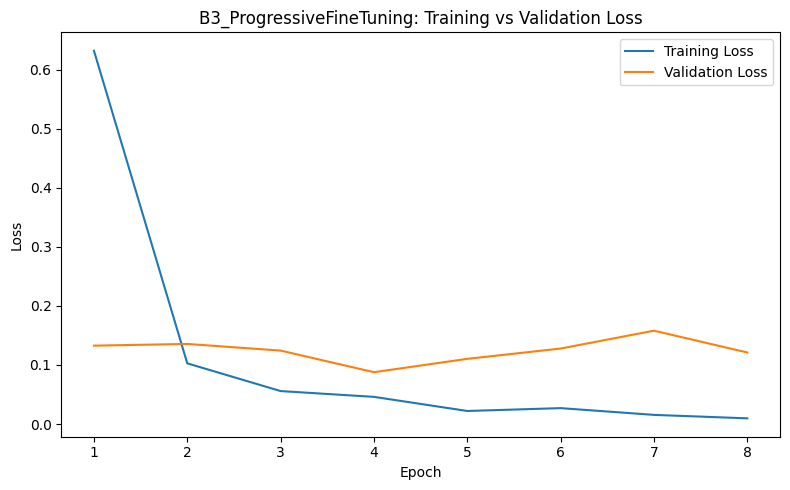

In [18]:
def plot_learning_curves(experiment_names):
    for experiment_name in experiment_names:
        hist = experiment_results[experiment_name]["history"]

        plt.figure(figsize=(8, 5))
        plt.plot(hist["epoch"], hist["train_loss"], label="Training Loss")
        plt.plot(hist["epoch"], hist["val_loss"], label="Validation Loss")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title(f"{experiment_name}: Training vs Validation Loss")
        plt.legend()
        plt.tight_layout()

        save_path = OUTPUT_DIR / f"{experiment_name}_loss_curve.png"
        plt.savefig(save_path, dpi=160, bbox_inches="tight")
        plt.show()

plot_learning_curves([
    "B1_Scratch",
    "B2_FeatureExtraction",
    "B3_ProgressiveFineTuning",
])

In [19]:
b2_val = experiment_results["B2_FeatureExtraction"]["summary"]["best_val_accuracy"]
b3_val = experiment_results["B3_ProgressiveFineTuning"]["summary"]["best_val_accuracy"]

if b3_val > b2_val:
    B4_BASE_STRATEGY = "B3"
else:
    B4_BASE_STRATEGY = "B2"

print("B2 validation accuracy:", b2_val)
print("B3 validation accuracy:", b3_val)
print("Selected strategy for B4:", B4_BASE_STRATEGY)

B2 validation accuracy: 96.96969696969697
B3 validation accuracy: 98.31649831649831
Selected strategy for B4: B3


In [20]:
b4_noaug_summary = run_experiment(
    experiment_name="B4_NoAug",
    strategy=B4_BASE_STRATEGY,
    use_augmentation=False,
)

EXPERIMENT: B4_NoAug
Strategy  : B3
Augment   : False
Trainable parameters: 8,398,858
Total parameters    : 11,181,642
Learning rates      : {'layer4': 0.0001, 'fc': 0.001}
Epoch 01/25 | train_loss=0.5406 | train_acc=86.22% | val_loss=0.1242 | val_acc=96.97%
Epoch 02/25 | train_loss=0.0447 | train_acc=99.35% | val_loss=0.1276 | val_acc=96.63%
Epoch 03/25 | train_loss=0.0181 | train_acc=99.93% | val_loss=0.1212 | val_acc=96.63%
Epoch 04/25 | train_loss=0.0117 | train_acc=100.00% | val_loss=0.0944 | val_acc=97.98%
Epoch 05/25 | train_loss=0.0059 | train_acc=100.00% | val_loss=0.1097 | val_acc=97.64%
Epoch 06/25 | train_loss=0.0034 | train_acc=100.00% | val_loss=0.1153 | val_acc=97.31%
Epoch 07/25 | train_loss=0.0029 | train_acc=100.00% | val_loss=0.1076 | val_acc=96.97%
Epoch 08/25 | train_loss=0.0023 | train_acc=100.00% | val_loss=0.1030 | val_acc=97.64%
Early stopping at epoch 8.

SUMMARY
experiment: B4_NoAug
architecture: resnet18
strategy: B3
augmentation: False
trainable_parameters:

In [21]:
b4_aug_summary = run_experiment(
    experiment_name="B4_Aug",
    strategy=B4_BASE_STRATEGY,
    use_augmentation=True,
)

EXPERIMENT: B4_Aug
Strategy  : B3
Augment   : True
Trainable parameters: 8,398,858
Total parameters    : 11,181,642
Learning rates      : {'layer4': 0.0001, 'fc': 0.001}
Epoch 01/25 | train_loss=0.6318 | train_acc=83.12% | val_loss=0.1327 | val_acc=96.30%
Epoch 02/25 | train_loss=0.1027 | train_acc=97.91% | val_loss=0.1356 | val_acc=94.95%
Epoch 03/25 | train_loss=0.0558 | train_acc=99.13% | val_loss=0.1243 | val_acc=96.30%
Epoch 04/25 | train_loss=0.0460 | train_acc=98.77% | val_loss=0.0878 | val_acc=98.32%
Epoch 05/25 | train_loss=0.0221 | train_acc=99.57% | val_loss=0.1104 | val_acc=97.31%
Epoch 06/25 | train_loss=0.0270 | train_acc=99.21% | val_loss=0.1278 | val_acc=97.31%
Epoch 07/25 | train_loss=0.0155 | train_acc=99.86% | val_loss=0.1580 | val_acc=96.63%
Epoch 08/25 | train_loss=0.0097 | train_acc=99.93% | val_loss=0.1211 | val_acc=97.98%
Early stopping at epoch 8.

SUMMARY
experiment: B4_Aug
architecture: resnet18
strategy: B3
augmentation: True
trainable_parameters: 8398858
to

In [22]:
b4_comparison = pd.DataFrame([
    experiment_results["B4_NoAug"]["summary"],
    experiment_results["B4_Aug"]["summary"],
])

display(
    b4_comparison[
        [
            "experiment",
            "augmentation",
            "best_val_accuracy",
            "train_accuracy_at_best_epoch",
            "generalization_gap_pct_points",
            "test_accuracy",
            "test_macro_f1",
            "training_time_sec",
        ]
    ]
)

,experiment,augmentation,best_val_accuracy,train_accuracy_at_best_epoch,generalization_gap_pct_points,test_accuracy,test_macro_f1,training_time_sec
0,B4_NoAug,False,97.979798,100.000000,2.020202,96.979866,0.969645,73.057391
1,B4_Aug,True,98.316498,98.773449,0.456950,96.644295,0.966366,109.381951


In [23]:

def build_efficientnet_b0(strategy):
    set_seed(SEED)

    weights = models.EfficientNet_B0_Weights.IMAGENET1K_V1
    model = models.efficientnet_b0(weights=weights)

    for param in model.parameters():
        param.requires_grad = False

    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(
        in_features,
        NUM_CLASSES
    )

    if strategy == "B2":
        param_groups = [
            {
                "params": model.classifier.parameters(),
                "lr": LR_HEAD,
            }
        ]

        lr_info = {
            "classifier": LR_HEAD,
        }

    elif strategy == "B3":
        for param in model.features[-2:].parameters():
            param.requires_grad = True

        param_groups = [
            {
                "params": model.features[-2:].parameters(),
                "lr": LR_BACKBONE,
            },
            {
                "params": model.classifier.parameters(),
                "lr": LR_HEAD,
            },
        ]

        lr_info = {
            "last_feature_stage": LR_BACKBONE,
            "classifier": LR_HEAD,
        }

    else:
        raise ValueError(
            "EfficientNet expects B2 or B3 strategy."
        )

    optimizer = torch.optim.AdamW(
        param_groups,
        weight_decay=WEIGHT_DECAY,
    )

    trainable, total = count_parameters(model)
    return model, optimizer, lr_info, trainable, total

B5 - EfficientNet-B0
Reference experiment: B3_ProgressiveFineTuning
Strategy: B3
Augmentation: True
EXPERIMENT: B5_EfficientNetB0
Strategy  : B3
Augment   : True
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 163MB/s]

Trainable parameters: 1,142,202
Total parameters    : 4,020,358
Learning rates      : {'last_feature_stage': 0.0001, 'classifier': 0.001}


Epoch 01/25 | train_loss=0.9532 | train_acc=83.55% | val_loss=0.1585 | val_acc=98.32%
Epoch 02/25 | train_loss=0.1677 | train_acc=96.83% | val_loss=0.0844 | val_acc=98.65%
Epoch 03/25 | train_loss=0.1031 | train_acc=97.91% | val_loss=0.0701 | val_acc=98.65%
Epoch 04/25 | train_loss=0.0914 | train_acc=97.47% | val_loss=0.0602 | val_acc=98.65%
Epoch 05/25 | train_loss=0.0614 | train_acc=98.56% | val_loss=0.0594 | val_acc=98.99%
Epoch 06/25 | train_loss=0.0487 | train_acc=98.63% | val_loss=0.0580 | val_acc=98.99%
Epoch 07/25 | train_loss=0.0395 | train_acc=99.28% | val_loss=0.0657 | val_acc=98.99%
Epoch 08/25 | train_loss=0.0275 | train_acc=99.28% | val_loss=0.0658 | val_acc=98.32%
Epoch 09/25 | train_loss=0.0327 | train_acc=98.99% | val_loss=0.0698 | val_acc=98.65%
Epoch 10/25 | train_loss=0.0223 | train_acc=99.64% | val_loss=0.0806 | val_acc=98.32%
Early stopping at epoch 10.

SUMMARY
experiment: B5_EfficientNetB0
architecture: efficientnet_b0
strategy: B3
augmentation: True
trainable_p

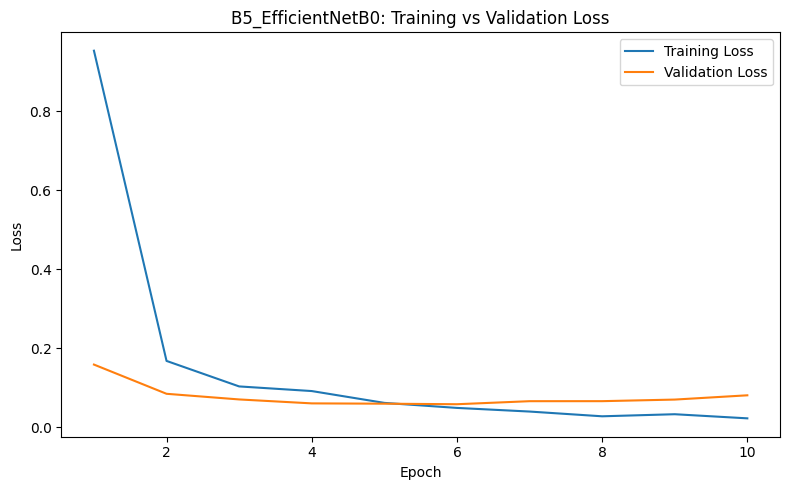

Saved B5 checkpoint: outputs/B5_EfficientNetB0_model_state.pt


,experiment,architecture,trainable_parameters,total_parameters,training_time_sec,best_val_accuracy,test_accuracy,test_macro_f1
0,B3_ProgressiveFineTuning,resnet18,8398858,11181642,108.858807,98.316498,96.644295,0.966366
1,B5_EfficientNetB0,efficientnet_b0,1142202,4020358,138.896209,98.989899,97.986577,0.979774


In [24]:
if RUN_B5:

    candidate_names = [
        "B2_FeatureExtraction",
        "B3_ProgressiveFineTuning",
        "B4_NoAug",
        "B4_Aug",
    ]

    best_transfer_experiment = max(
        candidate_names,
        key=lambda name: experiment_results[name]["summary"][
            "best_val_accuracy"
        ]
    )

    best_transfer_strategy = experiment_results[
        best_transfer_experiment
    ]["strategy"]

    best_transfer_aug = experiment_results[
        best_transfer_experiment
    ]["augmentation"]

    print("=" * 60)
    print("B5 - EfficientNet-B0")
    print("Reference experiment:", best_transfer_experiment)
    print("Strategy:", best_transfer_strategy)
    print("Augmentation:", best_transfer_aug)
    print("=" * 60)

    b5_summary = run_experiment(
        experiment_name="B5_EfficientNetB0",
        strategy=best_transfer_strategy,
        use_augmentation=best_transfer_aug,
        architecture="efficientnet_b0",
    )

    plot_learning_curves([
        "B5_EfficientNetB0"
    ])

    b5_checkpoint_path = (
        OUTPUT_DIR / "B5_EfficientNetB0_model_state.pt"
    )

    torch.save(
        {
            "experiment": "B5_EfficientNetB0",
            "state_dict": experiment_results[
                "B5_EfficientNetB0"
            ]["model"].state_dict(),
            "classes": resolved_selected_names,
            "summary": b5_summary,
        },
        b5_checkpoint_path,
    )

    print("Saved B5 checkpoint:", b5_checkpoint_path)

    b5_comparison = pd.DataFrame([
        experiment_results[
            best_transfer_experiment
        ]["summary"],
        b5_summary,
    ])

    display(
        b5_comparison[
            [
                "experiment",
                "architecture",
                "trainable_parameters",
                "total_parameters",
                "training_time_sec",
                "best_val_accuracy",
                "test_accuracy",
                "test_macro_f1",
            ]
        ]
    )

else:
    print("B5 experiment skipped.")

In [25]:
summary_rows = [
    result["summary"]
    for result in experiment_results.values()
]

summary_df = pd.DataFrame(summary_rows)

preferred_order = [
    "B1_Scratch",
    "B2_FeatureExtraction",
    "B3_ProgressiveFineTuning",
    "B4_NoAug",
    "B4_Aug",
    "B5_EfficientNetB0",
]

summary_df["sort_order"] = summary_df["experiment"].apply(
    lambda x: preferred_order.index(x)
    if x in preferred_order
    else 999
)

summary_df = (
    summary_df
    .sort_values("sort_order")
    .drop(columns="sort_order")
    .reset_index(drop=True)
)

epoch_df = pd.DataFrame(all_epoch_logs)

summary_csv_path = OUTPUT_DIR / "experiment_summary.csv"
summary_json_path = OUTPUT_DIR / "experiment_summary.json"
epoch_csv_path = OUTPUT_DIR / "epoch_metrics.csv"
config_json_path = OUTPUT_DIR / "experiment_config.json"

summary_df.to_csv(summary_csv_path, index=False)
summary_df.to_json(
    summary_json_path,
    orient="records",
    indent=2,
)

epoch_df.to_csv(epoch_csv_path, index=False)

config_payload = {
    "seed": SEED,
    "selected_classes": resolved_selected_names,
    "num_classes": NUM_CLASSES,
    "split": {
        "train": len(train_indices),
        "validation": len(val_indices),
        "test": len(test_indices),
    },
    "batch_size": BATCH_SIZE,
    "max_epochs": MAX_EPOCHS,
    "early_stopping_patience": PATIENCE,
    "optimizer": "AdamW",
    "loss": "CrossEntropyLoss",
    "weight_decay": WEIGHT_DECAY,
    "learning_rates": {
        "scratch": LR_SCRATCH,
        "head": LR_HEAD,
        "backbone_finetune": LR_BACKBONE,
    },
    "imagenet_normalization": {
        "mean": IMAGENET_MEAN,
        "std": IMAGENET_STD,
    },
}

with open(config_json_path, "w") as f:
    json.dump(config_payload, f, indent=2)

display(summary_df)

print("\nSaved:")
print(summary_csv_path)
print(summary_json_path)
print(epoch_csv_path)
print(config_json_path)

,experiment,architecture,strategy,augmentation,trainable_parameters,total_parameters,learning_rates,epochs_ran,best_epoch,training_time_sec,best_val_loss,best_val_accuracy,train_accuracy_at_best_epoch,generalization_gap_pct_points,test_accuracy,test_macro_f1
0,B1_Scratch,resnet18,B1,True,11181642,11181642,"{""all_parameters"": 0.001}",11,7,164.442641,1.516621,47.138047,47.041847,-0.096200,52.013423,0.499684
1,B2_FeatureExtraction,resnet18,B2,True,5130,11181642,"{""fc"": 0.001}",24,20,327.852039,0.099683,96.969697,98.484848,1.515152,96.979866,0.969933
2,B3_ProgressiveFineTuning,resnet18,B3,True,8398858,11181642,"{""layer4"": 0.0001, ""fc"": 0.001}",8,4,108.858807,0.087771,98.316498,98.773449,0.456950,96.644295,0.966366
3,B4_NoAug,resnet18,B3,False,8398858,11181642,"{""layer4"": 0.0001, ""fc"": 0.001}",8,4,73.057391,0.094369,97.979798,100.000000,2.020202,96.979866,0.969645
4,B4_Aug,resnet18,B3,True,8398858,11181642,"{""layer4"": 0.0001, ""fc"": 0.001}",8,4,109.381951,0.087771,98.316498,98.773449,0.456950,96.644295,0.966366
5,B5_EfficientNetB0,efficientnet_b0,B3,True,1142202,4020358,"{""last_feature_stage"": 0.0001, ""classifier"": 0...",10,6,138.896209,0.058027,98.989899,98.629149,-0.360750,97.986577,0.979774



Saved:
outputs/experiment_summary.csv
outputs/experiment_summary.json
outputs/epoch_metrics.csv
outputs/experiment_config.json


In [26]:
best_experiment_name = max(
    experiment_results.keys(),
    key=lambda name: experiment_results[name]["summary"]["best_val_accuracy"],
)

best_result = experiment_results[best_experiment_name]
best_model = best_result["model"]

print("Best experiment based on validation accuracy:")
print(best_experiment_name)
print(best_result["summary"])

Best experiment based on validation accuracy:
B5_EfficientNetB0
{'experiment': 'B5_EfficientNetB0', 'architecture': 'efficientnet_b0', 'strategy': 'B3', 'augmentation': True, 'trainable_parameters': 1142202, 'total_parameters': 4020358, 'learning_rates': '{"last_feature_stage": 0.0001, "classifier": 0.001}', 'epochs_ran': 10, 'best_epoch': 6, 'training_time_sec': 138.89620885099998, 'best_val_loss': 0.05802677675253815, 'best_val_accuracy': 98.98989898989899, 'train_accuracy_at_best_epoch': 98.62914862914863, 'generalization_gap_pct_points': -0.3607503607503588, 'test_accuracy': np.float64(97.98657718120806), 'test_macro_f1': 0.9797740112994351}


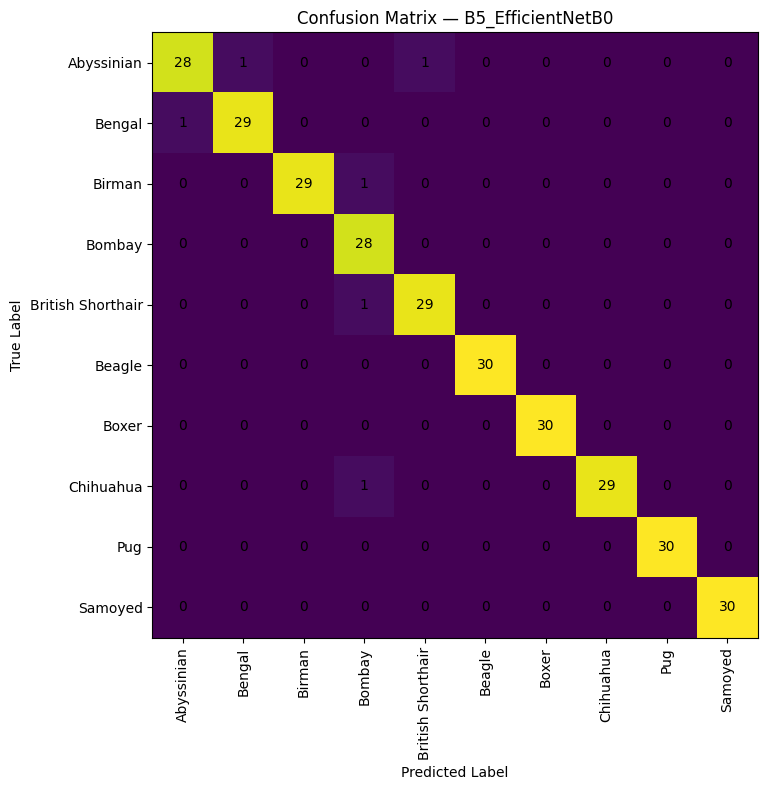

Saved: outputs/best_model_confusion_matrix.png


In [27]:
details = best_result["test_details"]

cm = confusion_matrix(
    details["y_true"],
    details["y_pred"],
    labels=list(range(NUM_CLASSES)),
)

plt.figure(figsize=(9, 8))
plt.imshow(cm)
plt.xticks(
    range(NUM_CLASSES),
    resolved_selected_names,
    rotation=90,
)
plt.yticks(
    range(NUM_CLASSES),
    resolved_selected_names,
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title(f"Confusion Matrix — {best_experiment_name}")

for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()

cm_path = OUTPUT_DIR / "best_model_confusion_matrix.png"
plt.savefig(cm_path, dpi=160, bbox_inches="tight")
plt.show()

print("Saved:", cm_path)

Total misclassified test images: 6


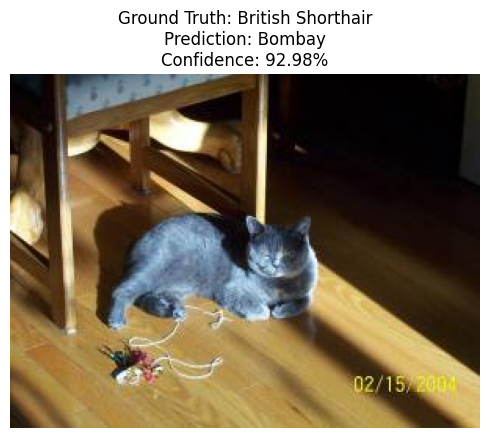

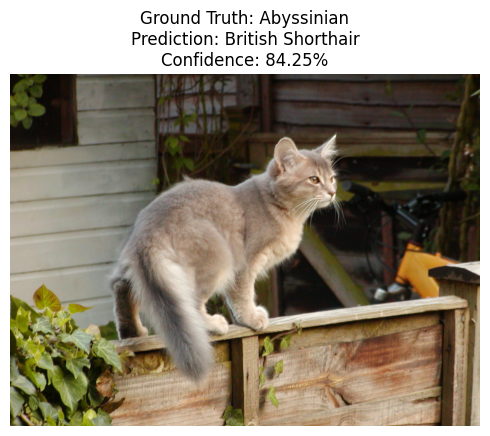

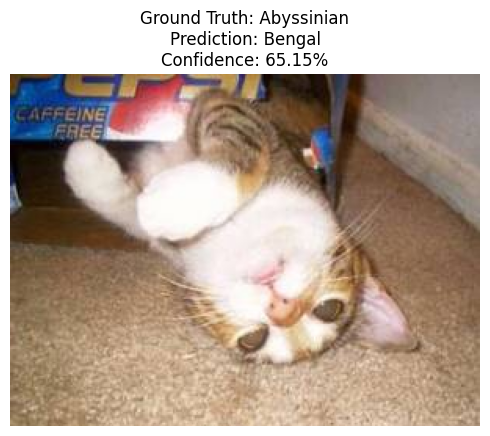

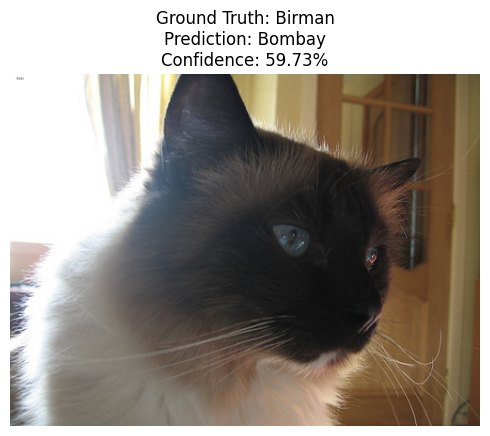

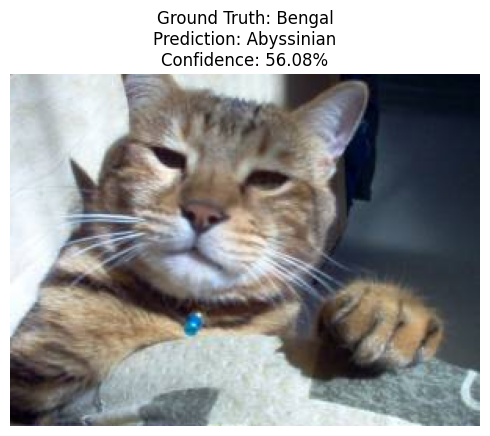

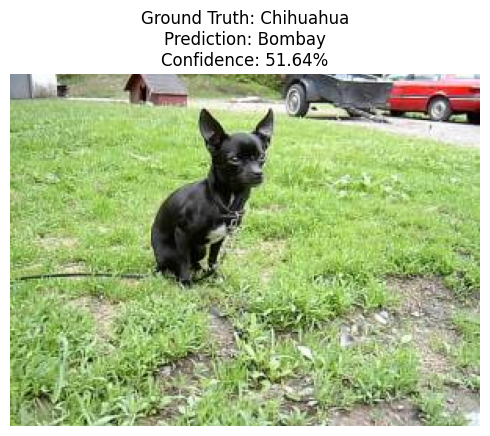

In [28]:
misclassified = details[
    details["y_true"] != details["y_pred"]
].copy()

misclassified = misclassified.sort_values(
    "confidence",
    ascending=False,
).reset_index(drop=True)

print("Total misclassified test images:", len(misclassified))

n_show = min(8, len(misclassified))

raw_test_dataset = OxfordPoolSubset(
    records_df,
    test_indices,
    trainval_base,
    test_base,
    transform=None,
)

for i in range(n_show):
    row = misclassified.iloc[i]
    record_idx = int(row["record_idx"])

    image, _ = raw_test_dataset.get_raw_by_record_idx(record_idx)

    true_name = resolved_selected_names[int(row["y_true"])]
    pred_name = resolved_selected_names[int(row["y_pred"])]
    confidence = 100.0 * float(row["confidence"])

    plt.figure(figsize=(5, 5))
    plt.imshow(image)
    plt.axis("off")
    plt.title(
        f"Ground Truth: {true_name}\n"
        f"Prediction: {pred_name}\n"
        f"Confidence: {confidence:.2f}%"
    )
    plt.tight_layout()
    plt.show()

In [29]:
misclassified_export = misclassified.copy()

misclassified_export["true_class"] = misclassified_export["y_true"].apply(
    lambda x: resolved_selected_names[int(x)]
)

misclassified_export["predicted_class"] = misclassified_export["y_pred"].apply(
    lambda x: resolved_selected_names[int(x)]
)

misclassified_export["confidence_percent"] = (
    misclassified_export["confidence"] * 100.0
)

misclassified_path = OUTPUT_DIR / "misclassified_samples.csv"
misclassified_export.to_csv(misclassified_path, index=False)

print("Saved:", misclassified_path)
display(misclassified_export.head(8))

Saved: outputs/misclassified_samples.csv


,record_idx,y_true,y_pred,confidence,true_class,predicted_class,confidence_percent
0,1587,4,3,0.929838,British Shorthair,Bombay,92.983842
1,523,0,4,0.842475,Abyssinian,British Shorthair,84.247541
2,1006,0,1,0.651514,Abyssinian,Bengal,65.151447
3,1354,2,3,0.597254,Birman,Bombay,59.725416
4,147,1,0,0.560792,Bengal,Abyssinian,56.079227
5,355,7,3,0.516407,Chihuahua,Bombay,51.640749


In [30]:
best_checkpoint_path = OUTPUT_DIR / f"{best_experiment_name}_best_model_state.pt"

torch.save(
    {
        "experiment": best_experiment_name,
        "state_dict": best_model.state_dict(),
        "classes": resolved_selected_names,
        "summary": best_result["summary"],
    },
    best_checkpoint_path,
)

print("Saved:", best_checkpoint_path)

Saved: outputs/B5_EfficientNetB0_best_model_state.pt


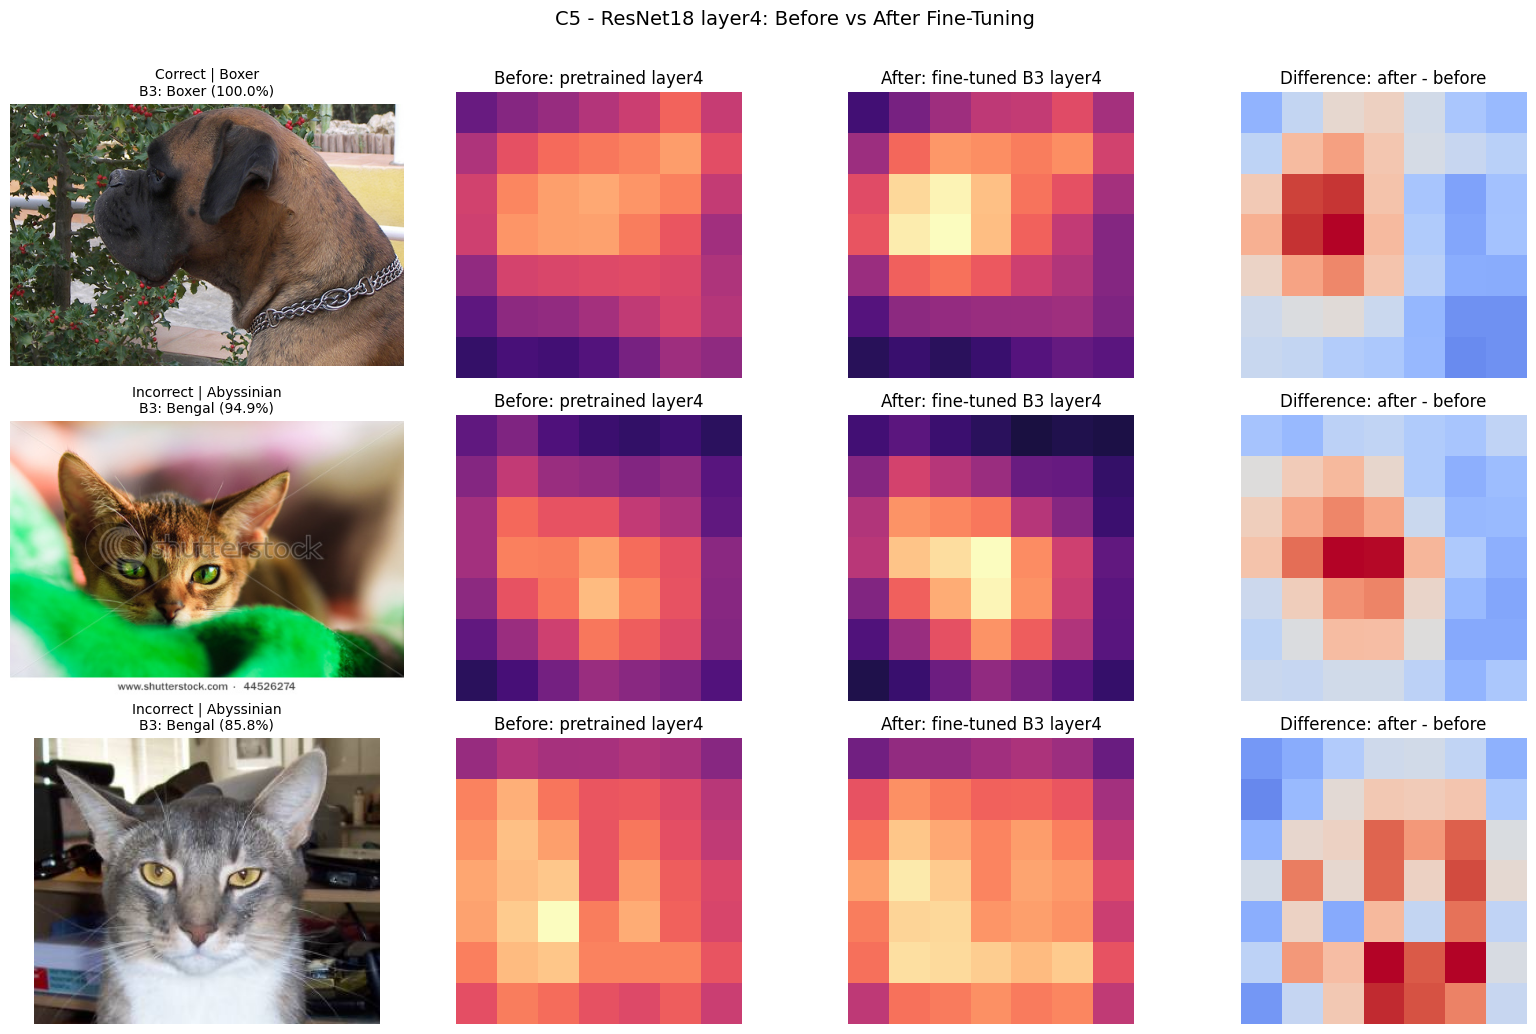

Saved C5 figure: outputs/C5_layer4_before_after_finetuning.png
Saved C5 metrics: outputs/C5_layer4_activation_comparison.csv


,record_idx,ground_truth,b3_prediction,b3_correct,b3_confidence_pct,mean_abs_layer4_change
0,777,Boxer,Boxer,True,99.999571,0.800204
1,1,Abyssinian,Bengal,False,94.943076,0.785079
2,1012,Abyssinian,Bengal,False,85.805655,0.750528


In [31]:
from IPython.display import display

b3_details = experiment_results[
    "B3_ProgressiveFineTuning"
]["test_details"].copy()

correct_b3 = b3_details[
    b3_details["y_true"] == b3_details["y_pred"]
]

wrong_b3 = b3_details[
    b3_details["y_true"] != b3_details["y_pred"]
]

c5_samples = pd.concat(
    [
        correct_b3.nlargest(1, "confidence"),
        wrong_b3.nlargest(2, "confidence"),
    ],
    ignore_index=True,
)

if len(c5_samples) < 3:
    remaining = b3_details[
        ~b3_details["record_idx"].isin(
            c5_samples["record_idx"]
        )
    ]

    c5_samples = pd.concat(
        [
            c5_samples,
            remaining.nsmallest(
                3 - len(c5_samples),
                "confidence",
            ),
        ],
        ignore_index=True,
    )

before_model = models.resnet18(
    weights=models.ResNet18_Weights.IMAGENET1K_V1
).to(device).eval()

after_model = copy.deepcopy(
    experiment_results[
        "B3_ProgressiveFineTuning"
    ]["model"]
).to(device).eval()

activations = {}

def capture_before(module, inputs, output):
    activations["before"] = output.detach().cpu()

def capture_after(module, inputs, output):
    activations["after"] = output.detach().cpu()

before_hook = before_model.layer4.register_forward_hook(
    capture_before
)

after_hook = after_model.layer4.register_forward_hook(
    capture_after
)

fig, axes = plt.subplots(
    nrows=len(c5_samples),
    ncols=4,
    figsize=(16, 3.5 * len(c5_samples)),
    squeeze=False,
)

c5_metrics = []

try:
    for row_idx, (_, sample) in enumerate(
        c5_samples.iterrows()
    ):
        record_idx = int(sample["record_idx"])

        raw_image, _ = (
            raw_test_dataset.get_raw_by_record_idx(
                record_idx
            )
        )

        tensor = eval_transform(
            raw_image
        ).unsqueeze(0).to(device)

        with torch.inference_mode():
            before_model(tensor)
            after_model(tensor)

        before_features = activations["before"].float()
        after_features = activations["after"].float()

        before_map = torch.linalg.vector_norm(
            before_features,
            dim=1,
        )[0].numpy()

        after_map = torch.linalg.vector_norm(
            after_features,
            dim=1,
        )[0].numpy()

        difference_map = after_map - before_map

        common_max = max(
            float(before_map.max()),
            float(after_map.max()),
            1e-8,
        )

        difference_max = max(
            float(np.abs(difference_map).max()),
            1e-8,
        )

        true_name = resolved_selected_names[
            int(sample["y_true"])
        ]

        pred_name = resolved_selected_names[
            int(sample["y_pred"])
        ]

        is_correct = (
            int(sample["y_true"])
            == int(sample["y_pred"])
        )

        confidence = float(sample["confidence"]) * 100

        axes[row_idx, 0].imshow(raw_image)
        axes[row_idx, 0].set_title(
            f"{'Correct' if is_correct else 'Incorrect'}"
            f" | {true_name}\n"
            f"B3: {pred_name} ({confidence:.1f}%)",
            fontsize=10,
        )

        axes[row_idx, 1].imshow(
            before_map,
            cmap="magma",
            vmin=0,
            vmax=common_max,
        )
        axes[row_idx, 1].set_title(
            "Before: pretrained layer4"
        )

        axes[row_idx, 2].imshow(
            after_map,
            cmap="magma",
            vmin=0,
            vmax=common_max,
        )
        axes[row_idx, 2].set_title(
            "After: fine-tuned B3 layer4"
        )

        axes[row_idx, 3].imshow(
            difference_map,
            cmap="coolwarm",
            vmin=-difference_max,
            vmax=difference_max,
        )
        axes[row_idx, 3].set_title(
            "Difference: after - before"
        )

        for ax in axes[row_idx]:
            ax.axis("off")

        c5_metrics.append({
            "record_idx": record_idx,
            "ground_truth": true_name,
            "b3_prediction": pred_name,
            "b3_correct": is_correct,
            "b3_confidence_pct": confidence,
            "mean_abs_layer4_change": float(
                torch.mean(
                    torch.abs(
                        after_features - before_features
                    )
                )
            ),
        })

finally:
    before_hook.remove()
    after_hook.remove()

fig.suptitle(
    "C5 - ResNet18 layer4: Before vs After Fine-Tuning",
    fontsize=14,
)

fig.tight_layout(rect=[0, 0, 1, 0.97])

c5_plot_path = (
    OUTPUT_DIR / "C5_layer4_before_after_finetuning.png"
)

fig.savefig(
    c5_plot_path,
    dpi=180,
    bbox_inches="tight",
)

plt.show()
plt.close(fig)

c5_csv_path = (
    OUTPUT_DIR / "C5_layer4_activation_comparison.csv"
)

pd.DataFrame(c5_metrics).to_csv(
    c5_csv_path,
    index=False,
)

print("Saved C5 figure:", c5_plot_path)
print("Saved C5 metrics:", c5_csv_path)

display(pd.DataFrame(c5_metrics))

del before_model, after_model

if torch.cuda.is_available():
    torch.cuda.empty_cache()

In [32]:
archive_base = "Tugas05_BagianB_outputs"

archive_path = shutil.make_archive(
    archive_base,
    "zip",
    OUTPUT_DIR,
)

print("Created archive:", archive_path)

Created archive: /content/Tugas05_BagianB_outputs.zip
